In [20]:
from utilities import utils_tomo
import numpy as np
import astra
import matplotlib.pyplot as plt
from alignment import tomoconsistency_tools_hannah

In [21]:
folder = '/mnt/share/ALC_ptychography_alignment/Experimental/connor_wright'
filename = folder + '/scan_275019_275199_tomo_complex.nxs'
data_key = '/entry1/data'
angle_key = '/entry1/rotation_angle'

stack_object, theta, _ = utils_tomo.load_data(filename, data_key= data_key, angle_key = angle_key)
print(stack_object.shape)
# stack_object = stack_object.transpose((1,2,0))
stack_object = stack_object.transpose((1,0,2)) # for astra
print(stack_object.shape)
[Ny, Nangles, Nx] = stack_object.shape
# [horizontal, angles, vertical]
# [Nlayers, width_sinogram]

raw data shape: (181, 582, 740)
projections shape: (181, 582, 740)
angles shape: (181,)
(181, 582, 740)
(582, 181, 740)


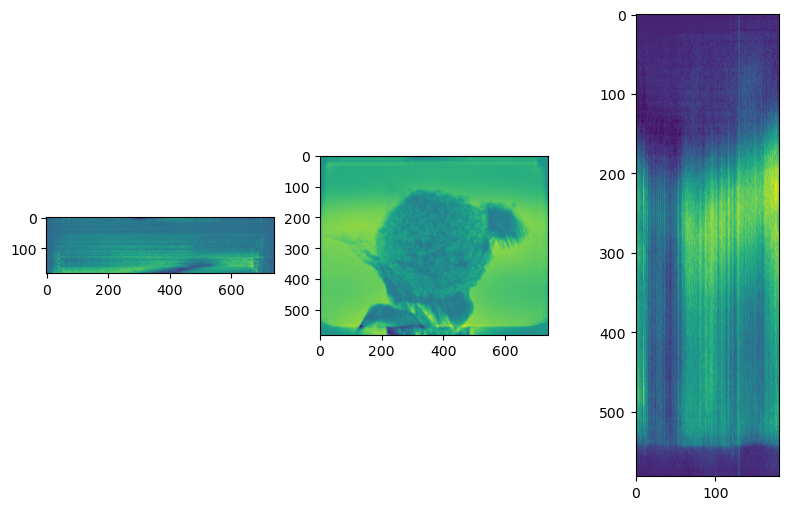

In [22]:
fig, axs = plt.subplots(1,3, figsize=(10,6))
axs[0].imshow(stack_object.real[0,:,:])
axs[1].imshow(stack_object.real[:,0,:])
axs[2].imshow(stack_object.real[:,:,0])

In [23]:
dtheta = np.zeros_like(theta)
dtheta[1:-1] = (theta[2:] - theta[:-2]) / 2
dtheta[0] = theta[1] - theta[0]
dtheta[-1] = theta[-1] - theta[-2]
# print(dtheta)
weights = dtheta / np.mean(dtheta)
print(weights)


[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [24]:
weights.shape

(181,)

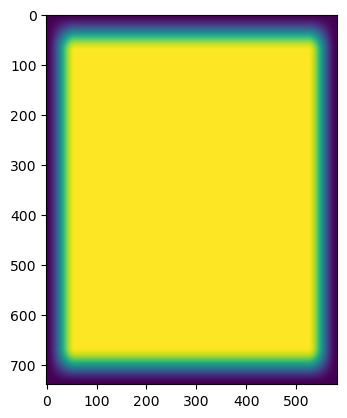

In [7]:
from scipy.signal.windows import tukey

win_h = tukey(Ny, 0.2)
win = win_h[np.newaxis, :]

align_vertical = True
if Nx > 10 and align_vertical:
    win_v = tukey(Nx, 0.2)[:, np.newaxis]
    win = win_v * win  
# apply in shift sinogram
plt.imshow(win)

In [28]:
stack_object.dtype

dtype('complex64')

In [29]:
vol_geom, proj_geom = tomoconsistency_tools_hannah.init_astra(Nx, Ny, theta)
rec = tomoconsistency_tools_hannah.FBP_astra(np.real(stack_object), vol_geom, proj_geom, weights)
sino = tomoconsistency_tools_hannah.get_projections(rec, vol_geom, proj_geom)

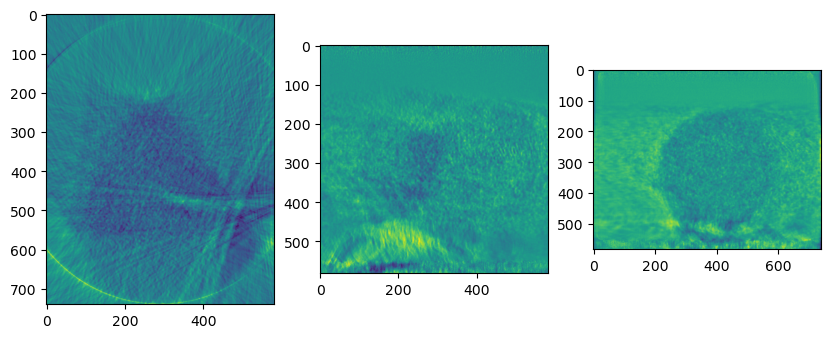

In [30]:
fig, axs = plt.subplots(1,3, figsize=(10,6))
i = 250
axs[0].imshow(rec[i,:,:])
axs[1].imshow(rec[:,i,:])
axs[2].imshow(rec[:,:,i])

In [ ]:
weights_shifted = weights
err = np.zeros_like(weights)
shift_upd = np.zeros_like(rec)
shift_total = np.zeros_like(rec)
iter = 10
binning = 1
tomoconsistency_tools_hannah.plot_alignment(rec, rec, weights_shifted, err,
                   shift_upd, shift_total, theta, theta, iter, binning)

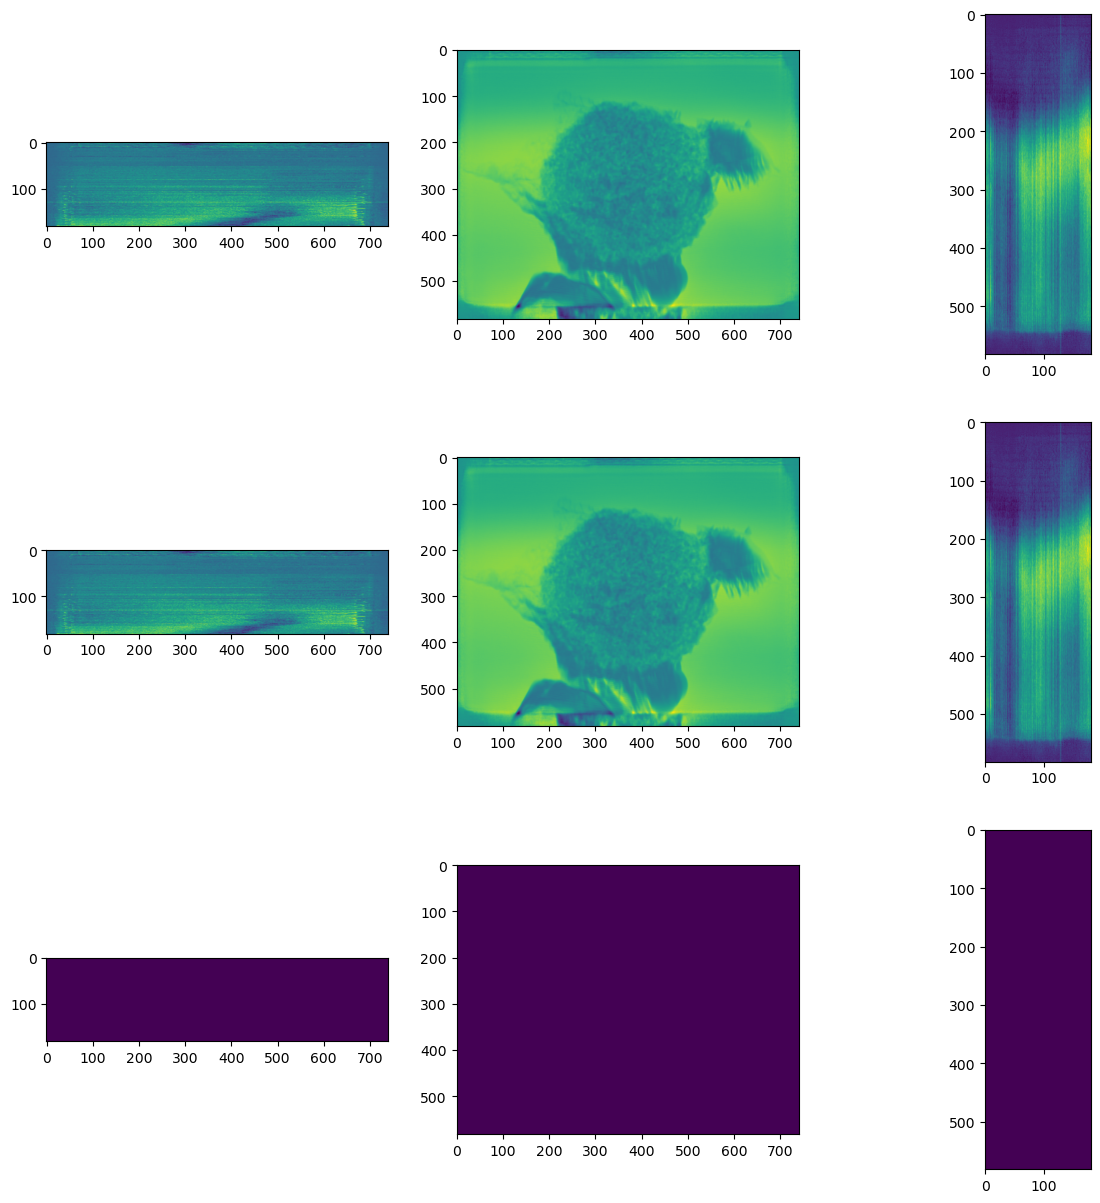

In [26]:
stack_transform = tomoconsistency_tools_hannah.imdeform_affine_fft(stack_object)
fig, axs = plt.subplots(3,3, figsize=(15,15))

axs[0,0].imshow(stack_object.real[0,:,:])
axs[0,1].imshow(stack_object.real[:,0,:])
axs[0,2].imshow(stack_object.real[:,:,0])

axs[1,0].imshow(stack_transform.real[0,:,:])
axs[1,1].imshow(stack_transform.real[:,0,:])
axs[1,2].imshow(stack_transform.real[:,:,0])

axs[2,0].imshow(stack_object.real[0,:,:]-stack_transform.real[0,:,:])
axs[2,1].imshow(stack_object.real[:,0,:]-stack_transform.real[:,0,:])
axs[2,2].imshow(stack_object.real[:,:,0]-stack_transform.real[:,:,0])